# Capstone — Analysing Insurance Claims for SafeDrive Insurance Ltd.

# Notebook 3 — AutoML Model Comparison & Versioning

Notebook 2 built a logistic regression baseline and an Optuna-tuned decision tree on
**hand-engineered** features. This notebook asks a different question:

> Can **automated** feature synthesis find interactions that manual feature engineering missed?

Featuretools' Deep Feature Synthesis generates candidate interaction features mechanically, each is
screened against the strongest hand-built feature, and the survivors are fed to a freshly tuned
decision tree. The result is tracked, versioned and explained on its own — deliberately kept
separate from Notebook 2 so the two pipelines can be compared rather than confused.

**Contents**
1. Featuretools Deep Feature Synthesis and correlation-based screening
2. AutoML-extended decision tree, tuned with Optuna
3. Baseline comparison and model selection
4. MLflow tracking (separate AutoML experiment), versioning, Evidently
5. SHAP explainability — including whether any synthesised feature earns a place in the top 10
6. Final predictions, risk banding, and portfolio KPIs


In [ ]:
# ================= Imports and configuration =================
import json, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime, timezone

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                             RocCurveDisplay, classification_report)

RANDOM_STATE = 42

OUT_DIR = Path('stage3_outputs')
OUT_DIR.mkdir(exist_ok=True)
print("Artifacts directory:", OUT_DIR.resolve())


# ================= Load the Notebook 1 output =================
def resolve_dataset_path():
    """Locate the Notebook 1 output wherever it happens to be placed.

    Checked in order: the notebook directory, common sub-folders, the parent
    directory, and /mnt/user-data/uploads. Falls back to any cleaned_dataset*.csv
    so a suffixed copy (e.g. cleaned_dataset-final.csv) still resolves.
    """
    names = ['cleaned_dataset.csv', 'cleaned_dataset-final.csv',
             'cleaned_dataset_final.csv', 'dataset.csv']
    dirs = [Path.cwd(), Path.cwd() / 'stage1_outputs', Path.cwd() / 'archive',
            Path.cwd() / 'data', Path.cwd().parent, Path('/mnt/user-data/uploads')]

    for d in dirs:
        for n in names:
            if (d / n).exists():
                return d / n
    for d in dirs:
        hits = sorted(d.glob('cleaned_dataset*.csv')) if d.exists() else []
        if hits:
            return hits[0]
    raise FileNotFoundError(
        "cleaned_dataset.csv could not be found. Searched:\n  "
        + "\n  ".join(str(d) for d in dirs))


DATA_PATH = resolve_dataset_path()
df = pd.read_csv(DATA_PATH)

print("\nResolved path  :", DATA_PATH)
print("Shape          :", df.shape)
print("Missing values :", df.isnull().sum().sum())
print("Duplicate rows :", int(df.duplicated().sum()))
print("Claim rate     :", round(df['is_claim'].mean(), 4))

df.head(3)


Artifacts directory: /content/stage3_outputs

Resolved path  : /content/cleaned_dataset.csv
Shape          : (58592, 108)
Missing values : 0
Duplicate rows : 0
Claim rate     : 0.064


,policy_id,policy_tenure,age_of_car,age_of_policyholder,airbags,is_esc,is_adjustable_steering,is_tpms,is_parking_sensors,is_parking_camera,...,model_M5,model_M6,model_M7,model_M8,model_M9,make_1,make_2,make_3,make_4,make_5
0,ID00001,0.515874,0.05,0.644231,2,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
1,ID00002,0.672619,0.02,0.375000,2,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
2,ID00003,0.841110,0.02,0.384615,2,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0


## The Base Feature Set and Reference Split

Everything starts from exactly the same base feature set and the same stratified 80/20 split used
in Notebook 2. Holding the split fixed is what makes the AutoML comparison meaningful — any
difference in performance has to come from the *features*, not from a luckier set of rows.


In [ ]:
# ================= Base feature set (identical to Notebook 2) =================
drop_cols = ['is_claim', 'policy_id']
for raw, log in [('age_of_car', 'age_of_car_log'),
                 ('population_density', 'population_density_log')]:
    if raw in df.columns and log in df.columns:
        drop_cols.append(raw)

feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols]
y = df['is_claim']

# The reference split — every later split is asserted against this one
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

print(f"Base features  : {len(feature_cols)}")
print(f"Train / Test   : {X_train.shape[0]:,} / {X_test.shape[0]:,}")
print(f"Claim rate     : train {y_train.mean():.4f} | test {y_test.mean():.4f}")

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

Base features  : 106
Train / Test   : 46,873 / 11,719
Claim rate     : train 0.0640 | test 0.0640


## Featuretools — Deep Feature Synthesis

Deep Feature Synthesis builds candidate features mechanically by applying transform primitives to
combinations of input columns. We use `multiply_numeric` and `add_numeric` at `max_depth=1`, which
generates every pairwise product and sum of the input columns.

**Two design decisions worth stating explicitly.**

**The target is excluded from the EntitySet.** `is_claim` never enters the entity. If it did, DFS
would happily build features like `is_claim * policy_tenure`, which would leak the answer into the
feature set and produce a model that looks perfect and predicts nothing.

**DFS runs on the multi-level numeric columns, not all 106 base features.** Pairwise combination is
quadratic: all 106 columns would generate 11,130 candidates, which at 58,592 rows is roughly 5 GB of
dense float — before any screening. It would also be analytically pointless, since most of those
106 columns are one-hot dummies and binary flags, and multiplying two mutually exclusive dummies
produces a column of zeros. Restricting to the multi-level numerics keeps the search space
meaningful and tractable.


In [ ]:
!pip install -q featuretools

import featuretools as ft

# ---------- Inputs: multi-level numeric columns only ----------
dfs_input_cols = [c for c in feature_cols if df[c].nunique() > 2]

print(f"DFS input columns: {len(dfs_input_cols)}")
print(dfs_input_cols)

# ---------- Build the EntitySet — TARGET EXCLUDED ----------
dfs_frame = df[dfs_input_cols].copy()
dfs_frame['policy_index'] = np.arange(len(df))       # required unique index

assert 'is_claim' not in dfs_frame.columns, "TARGET LEAKAGE — is_claim must not enter the EntitySet"
print(f"\nTarget excluded from EntitySet: {'is_claim' not in dfs_frame.columns}")

es = ft.EntitySet(id='safedrive')
es = es.add_dataframe(dataframe_name='policies',
                      dataframe=dfs_frame,
                      index='policy_index')
print(es)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 587.9/587.9 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.2/215.2 kB 11.1 MB/s eta 0:00:00
DFS input columns: 19
['policy_tenure', 'age_of_car', 'age_of_policyholder', 'airbags', 'displacement', 'turning_radius', 'length', 'width', 'height', 'gross_weight', 'ncap_rating', 'max_power_bhp', 'max_torque_nm', 'power_rpm', 'torque_rpm', 'population_density_log', 'safety_equipment_count', 'power_to_weight', 'tenure_age_interaction']

Target excluded from EntitySet: True
Entityset: safedrive
  DataFrames:
    policies [Rows: 58592, Columns: 20]
  Relationships:
    No relationships


In [ ]:
# ---------- Run Deep Feature Synthesis ----------
feature_matrix, feature_defs = ft.dfs(
    entityset=es,
    target_dataframe_name='policies',
    trans_primitives=['multiply_numeric', 'add_numeric'],
    max_depth=1)

# Feature names come from feature_matrix.columns.
# NOTE: str(feature_defs) would give '<Feature: ...>' wrappers, not usable column names.
dfs_feature_names = list(feature_matrix.columns)
new_candidates    = [c for c in dfs_feature_names if c not in dfs_input_cols]

print(f"Feature matrix shape        : {feature_matrix.shape}")
print(f"Total DFS features          : {len(dfs_feature_names)}")
print(f"  original passthrough      : {len(dfs_input_cols)}")
print(f"  newly generated candidates: {len(new_candidates)}")

print(f"\nAll {len(new_candidates)} generated candidate names:")
for i in range(0, len(new_candidates), 3):
    print("   " + "".join(f"{n:44s}" for n in new_candidates[i:i + 3]).rstrip())


Feature matrix shape        : (58592, 361)
Total DFS features          : 361
  original passthrough      : 19
  newly generated candidates: 342

All 342 generated candidate names:
   age_of_car + age_of_policyholder            age_of_car + airbags                        age_of_car + displacement
   age_of_car + gross_weight                   age_of_car + height                         age_of_car + length
   age_of_car + max_power_bhp                  age_of_car + max_torque_nm                  age_of_car + ncap_rating
   age_of_car + policy_tenure                  age_of_car + population_density_log         age_of_car + power_rpm
   age_of_car + power_to_weight                age_of_car + safety_equipment_count         age_of_car + tenure_age_interaction
   age_of_car + torque_rpm                     age_of_car + turning_radius                 age_of_car + width
   age_of_policyholder + airbags               age_of_policyholder + displacement          age_of_policyholder + gross_weight

### Screening the Candidates

342 mechanically generated features is not an improvement — it is 342 opportunities to overfit.
Most are near-copies of their parents: multiplying `policy_tenure` by a vehicle dimension mostly
reproduces `policy_tenure`.

The screening rule is deliberately strict. We compute `best_base_corr`, the strongest absolute
correlation any **existing** feature has with the target, and keep a generated feature only if it
**beats that bar**. A candidate does not merely have to be useful — it has to be more useful than
the best thing we already had. Anything weaker adds dimensionality without adding information.

Infinite and missing values are replaced with 0 before correlating, since products of large
columns can overflow and a single `inf` would make the correlation undefined.


In [ ]:
# ---------- Clean the generated matrix ----------
feature_matrix = feature_matrix.replace([np.inf, -np.inf], np.nan).fillna(0)
print(f"Non-finite values remaining: {int((~np.isfinite(feature_matrix.values)).sum())}")

# ---------- The bar to beat: best correlation among existing features ----------
base_corr = {c: abs(df[c].corr(df['is_claim'])) for c in feature_cols}
base_corr = pd.Series(base_corr).replace([np.inf, -np.inf], np.nan).fillna(0)
best_base_corr = base_corr.max()

print(f"\nStrongest existing feature : {base_corr.idxmax()}")
print(f"best_base_corr             : {best_base_corr:.5f}")

# ---------- Score every candidate ----------
y_vals = df['is_claim'].values
cand_corr = {}
for c in new_candidates:
    v = feature_matrix[c].values.astype(float)
    cand_corr[c] = 0.0 if np.std(v) == 0 else abs(np.corrcoef(v, y_vals)[0, 1])

cand_corr = pd.Series(cand_corr).replace([np.inf, -np.inf], np.nan).fillna(0).sort_values(ascending=False)

print("\nTop 10 generated candidates by |correlation with is_claim|:")
print(cand_corr.head(10).round(5).to_string())

# ---------- Retain only those that beat the bar ----------
featuretools_features = cand_corr[cand_corr > best_base_corr].index.tolist()

print(f"\nCandidates generated : {len(new_candidates)}")
print(f"Candidates retained  : {len(featuretools_features)} "
      f"({len(featuretools_features) / len(new_candidates) * 100:.1f}%)")
for f in featuretools_features:
    print(f"    {f:45s} |corr| = {cand_corr[f]:.5f}  (bar {best_base_corr:.5f})")

Non-finite values remaining: 0

Strongest existing feature : policy_tenure
best_base_corr             : 0.07875

Top 10 generated candidates by |correlation with is_claim|:
policy_tenure + tenure_age_interaction    0.07935
policy_tenure * width                     0.07890
age_of_policyholder + policy_tenure       0.07883
policy_tenure + power_to_weight           0.07840
length * policy_tenure                    0.07838
policy_tenure * turning_radius            0.07834
height * policy_tenure                    0.07827
policy_tenure * population_density_log    0.07713
gross_weight * policy_tenure              0.07649
tenure_age_interaction * width            0.07599

Candidates generated : 342
Candidates retained  : 3 (0.9%)
    policy_tenure + tenure_age_interaction        |corr| = 0.07935  (bar 0.07875)
    policy_tenure * width                         |corr| = 0.07890  (bar 0.07875)
    age_of_policyholder + policy_tenure           |corr| = 0.07883  (bar 0.07875)


In [ ]:
# ---------- Merge the retained features onto the dataset ----------
df_fe = df.copy()
for c in featuretools_features:
    df_fe[c] = feature_matrix[c].values

extended_feature_cols = feature_cols + featuretools_features

print(f"df_fe shape             : {df_fe.shape}")
print(f"Base feature count      : {len(feature_cols)}")
print(f"Extended feature count  : {len(extended_feature_cols)}")
print(f"Featuretools additions  : {len(featuretools_features)}")
print(f"\nNo NaN introduced by the merge: {df_fe[extended_feature_cols].isna().sum().sum() == 0}")

df_fe shape             : (58592, 111)
Base feature count      : 106
Extended feature count  : 109
Featuretools additions  : 3

No NaN introduced by the merge: True


**Interpretation — what automated feature synthesis actually found.**

Of **342 generated candidates, only 3 cleared the bar** — under 1%. That is the honest headline, and
it is worth reading carefully rather than treating as a disappointment.

The three survivors are `policy_tenure + tenure_age_interaction`, `policy_tenure * width`, and
`age_of_policyholder + policy_tenure`. Every one of them contains `policy_tenure`, and every one
improves on it by a hair — correlations of 0.0794, 0.0789 and 0.0788 against the 0.0788 bar set by
`policy_tenure` alone.

This tells us something real. DFS did not discover a hidden driver of claim risk; it found
*re-weightings of the driver we already knew about*. `policy_tenure * width` is not a story about
vehicle width — width is essentially uncorrelated with claims — it is `policy_tenure` scaled by a
roughly constant factor. The gains are third-decimal-place.

That is itself a useful result for the business report: it is **evidence that the manual feature
engineering in Notebook 1 was close to exhaustive** for this dataset. When brute-force generation of
every pairwise product and sum cannot beat hand-built features by a meaningful margin, the ceiling
is in the data, not in the feature engineering. More claim signal will come from new data sources —
telematics, prior claims history, behavioural data — not from more clever recombination of what is
already here.


## AutoML-Extended Decision Tree

The extended feature set now goes to a decision tree tuned from scratch with Optuna.

Three safeguards, in order. The extended split is **asserted** to contain exactly the same rows as
the base split. A **fresh** `ColumnTransformer` is fitted on `X_train2` only — critically, the newly
synthesised features have never been seen by any fitted scaler, so they must be scaled using
training statistics alone. And tuning is scored on 3-fold CV within the training set, leaving the
test set untouched.


In [ ]:
# ---------- Rebuild the split on extended features ----------
X_ext = df_fe[extended_feature_cols]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_ext, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

# The rows MUST be identical to the base split
assert X_train2.index.equals(X_train.index), "Extended training split differs from the base split"
assert X_test2.index.equals(X_test.index),   "Extended test split differs from the base split"
assert y_train2.equals(y_train) and y_test2.equals(y_test)

print("Row-index assertions passed.")
print(f"  Train rows identical to base split: {X_train2.index.equals(X_train.index)}")
print(f"  Test  rows identical to base split: {X_test2.index.equals(X_test.index)}")
print(f"\nBase feature matrix    : {X_train.shape}")
print(f"Extended feature matrix: {X_train2.shape}  (+{len(featuretools_features)} synthesised)")


def build_preprocessor(cols, frame):
    """A fresh, unfitted ColumnTransformer for `cols`, typed against `frame`.

    The frame is passed in explicitly so the same helper can serve the base and
    the extended feature sets without depending on module-level state.
    """
    numeric     = [c for c in cols if pd.api.types.is_numeric_dtype(frame[c])]
    categorical = [c for c in cols if c not in numeric]
    return ColumnTransformer(
        transformers=[('num', StandardScaler(), numeric),
                      ('cat', OneHotEncoder(handle_unknown='ignore'), categorical)],
        remainder='drop')


# Fresh preprocessor fitted on the EXTENDED training data only
preprocessor2 = build_preprocessor(extended_feature_cols, X_ext)
preprocessor2.fit(X_train2)

n_num = len(preprocessor2.transformers_[0][2])
n_cat = len(preprocessor2.transformers_[1][2])
print(f"\nFresh ColumnTransformer fitted on X_train2 only "
      f"({preprocessor2.transform(X_train2).shape[1]} output columns; "
      f"{n_num} numeric scaled, {n_cat} categorical one-hot).")

Row-index assertions passed.
  Train rows identical to base split: True
  Test  rows identical to base split: True

Base feature matrix    : (46873, 106)
Extended feature matrix: (46873, 109)  (+3 synthesised)

Fresh ColumnTransformer fitted on X_train2 only (109 output columns; 109 numeric scaled, 0 categorical one-hot).


In [ ]:
# ================= Environment setup =================
!pip install -q featuretools optuna mlflow evidently shap

# ================= Optuna tuning on the extended feature set =================
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


def objective(trial):
    params = {
        'max_depth':         trial.suggest_int('max_depth', 3, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 50),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 30)}

    pipe = Pipeline([
        ('pre', build_preprocessor(extended_feature_cols, X_ext)),
        ('clf', DecisionTreeClassifier(**params,
                                       class_weight='balanced',
                                       random_state=RANDOM_STATE))])

    return cross_val_score(pipe, X_train2, y_train2,
                           cv=cv3, scoring='roc_auc').mean()


study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    study_name='automl_decision_tree_tuning')

study.optimize(objective, n_trials=25, show_progress_bar=False)

print(f"Trials completed : {len(study.trials)}")
print(f"Best CV ROC-AUC  : {study.best_value:.4f}")
print("Best parameters  :")
for k, v in study.best_params.items():
    print(f"    {k:20s}: {v}")

print("\nTop 5 trials:")
print(study.trials_dataframe()[['number', 'value', 'params_max_depth',
                                'params_min_samples_split', 'params_min_samples_leaf']]
      .sort_values('value', ascending=False).head().round(4).to_string(index=False))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.4/271.4 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.

In [ ]:
# ---------- Fit and evaluate the tuned tree on the extended test set ----------
dt_automl = Pipeline([
    ('pre', build_preprocessor(extended_feature_cols, X_ext)),
    ('clf', DecisionTreeClassifier(**study.best_params,
                                   class_weight='balanced',
                                   random_state=RANDOM_STATE))])
dt_automl.fit(X_train2, y_train2)


def evaluate(model, X_eval, y_eval, label):
    y_pred  = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1]
    return {'model': label,
            'accuracy':  accuracy_score(y_eval, y_pred),
            'precision': precision_score(y_eval, y_pred, zero_division=0),
            'recall':    recall_score(y_eval, y_pred),
            'f1':        f1_score(y_eval, y_pred),
            'roc_auc':   roc_auc_score(y_eval, y_proba)}


dt_metrics = evaluate(dt_automl, X_test2, y_test2, 'DecisionTree_AutoML_extended')

print("AutoML-extended decision tree — test set\n")
for k in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    print(f"  {k.replace('_', '-').title():10s}: {dt_metrics[k]:.4f}")

print("\n", classification_report(y_test2, dt_automl.predict(X_test2),
                                   target_names=['No Claim', 'Claim'], digits=3))

AutoML-extended decision tree — test set

  Accuracy  : 0.5152
  Precision : 0.0879
  Recall    : 0.7013
  F1        : 0.1562
  Roc-Auc   : 0.6336

               precision    recall  f1-score   support

    No Claim      0.961     0.503     0.660     10969
       Claim      0.088     0.701     0.156       750

    accuracy                          0.515     11719
   macro avg      0.524     0.602     0.408     11719
weighted avg      0.905     0.515     0.628     11719



## Baseline Comparison and Model Selection

The logistic regression baseline is refitted here on the **base (non-extended)** feature set. That
asymmetry is intentional: the comparison is "hand-engineered baseline versus AutoML-extended tree",
so the baseline must not receive the synthesised features.

Both models are scored by 5-fold cross-validation on their own training data and on the same test
rows. The winner is selected on **test ROC-AUC**.


In [ ]:
# ---------- Baseline: logistic regression on BASE features ----------
lr_baseline = Pipeline([
    ('pre', build_preprocessor(feature_cols, X)),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000,
                               random_state=RANDOM_STATE))])
lr_baseline.fit(X_train, y_train)

lr_metrics = evaluate(lr_baseline, X_test, y_test, 'LogisticRegression_baseline')

# ---------- 5-fold cross-validation for both ----------
lr_cv_auc = cross_val_score(lr_baseline, X_train,  y_train,  cv=cv5, scoring='roc_auc')
lr_cv_f1  = cross_val_score(lr_baseline, X_train,  y_train,  cv=cv5, scoring='f1')
dt_cv_auc = cross_val_score(dt_automl,   X_train2, y_train2, cv=cv5, scoring='roc_auc')
dt_cv_f1  = cross_val_score(dt_automl,   X_train2, y_train2, cv=cv5, scoring='f1')

print(f"Baseline LR   — CV ROC-AUC {lr_cv_auc.mean():.4f} +/- {lr_cv_auc.std():.4f} | "
      f"CV F1 {lr_cv_f1.mean():.4f} +/- {lr_cv_f1.std():.4f}")
print(f"AutoML DT     — CV ROC-AUC {dt_cv_auc.mean():.4f} +/- {dt_cv_auc.std():.4f} | "
      f"CV F1 {dt_cv_f1.mean():.4f} +/- {dt_cv_f1.std():.4f}")

Baseline LR   — CV ROC-AUC 0.6097 +/- 0.0054 | CV F1 0.1485 +/- 0.0020
AutoML DT     — CV ROC-AUC 0.6351 +/- 0.0089 | CV F1 0.1600 +/- 0.0039


AutoML model comparison

                              accuracy  precision  recall      f1  roc_auc              feature_set  n_features  cv_roc_auc_mean  cv_roc_auc_std  cv_f1_mean  cv_f1_std
model                                                                                                                                                                  
LogisticRegression_baseline     0.5634     0.0797  0.5520  0.1393   0.5850                     base         106           0.6097          0.0054      0.1485     0.0020
DecisionTree_AutoML_extended    0.5152     0.0879  0.7013  0.1562   0.6336  extended (Featuretools)         109           0.6351          0.0089      0.1600     0.0039

SELECTED MODEL : DecisionTree_AutoML_extended
  Test ROC-AUC : 0.6336
  Feature set  : extended (Featuretools) (109 features)


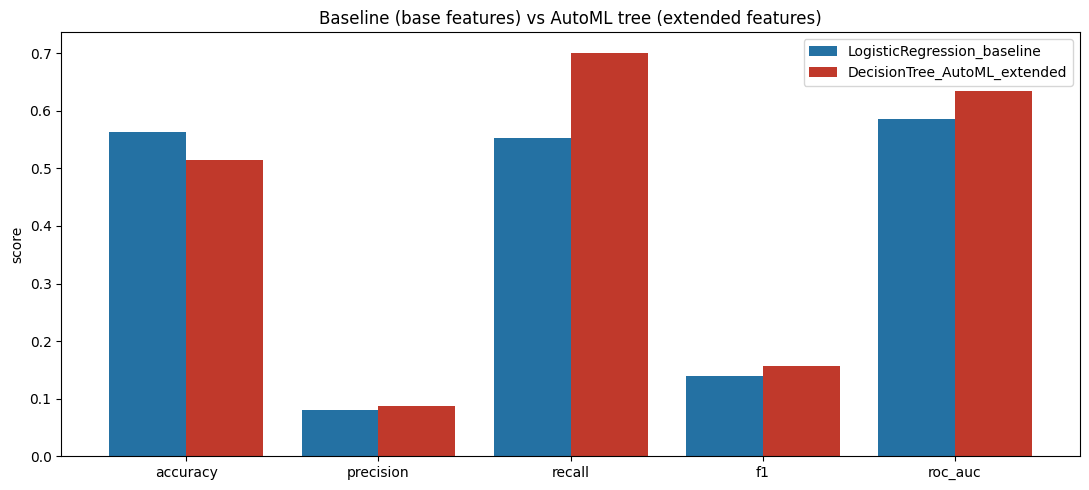

In [ ]:
# ---------- Comparison table ----------
comparison = pd.DataFrame([
    {**lr_metrics, 'feature_set': 'base',
     'n_features': len(feature_cols),
     'cv_roc_auc_mean': lr_cv_auc.mean(), 'cv_roc_auc_std': lr_cv_auc.std(),
     'cv_f1_mean': lr_cv_f1.mean(),       'cv_f1_std': lr_cv_f1.std()},
    {**dt_metrics, 'feature_set': 'extended (Featuretools)',
     'n_features': len(extended_feature_cols),
     'cv_roc_auc_mean': dt_cv_auc.mean(), 'cv_roc_auc_std': dt_cv_auc.std(),
     'cv_f1_mean': dt_cv_f1.mean(),       'cv_f1_std': dt_cv_f1.std()}
]).set_index('model').round(4)

print("AutoML model comparison\n")
print(comparison.to_string())

comparison.to_csv(OUT_DIR / 'model_comparison_automl.csv')

# ---------- Select the winner on test ROC-AUC ----------
winner = comparison['roc_auc'].idxmax()
models  = {'LogisticRegression_baseline': lr_baseline,
           'DecisionTree_AutoML_extended': dt_automl}

chosen_name    = winner
chosen_model   = models[winner]
chosen_metrics = lr_metrics if winner.startswith('Logistic') else dt_metrics
is_lr          = winner.startswith('Logistic')
chosen_features                = feature_cols if is_lr else extended_feature_cols
chosen_X_train, chosen_y_train = (X_train, y_train) if is_lr else (X_train2, y_train2)
chosen_X_test,  chosen_y_test  = (X_test,  y_test)  if is_lr else (X_test2,  y_test2)
chosen_cv_auc                  = lr_cv_auc if is_lr else dt_cv_auc

print(f"\nSELECTED MODEL : {chosen_name}")
print(f"  Test ROC-AUC : {comparison.loc[winner, 'roc_auc']:.4f}")
print(f"  Feature set  : {comparison.loc[winner, 'feature_set']} "
      f"({comparison.loc[winner, 'n_features']} features)")

ax = comparison[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']].T.plot(
    kind='bar', figsize=(11, 5), width=0.8, color=['#2471a3', '#c0392b'])
ax.set_ylabel('score'); ax.set_title('Baseline (base features) vs AutoML tree (extended features)')
ax.tick_params(axis='x', rotation=0); ax.legend(title='')
plt.tight_layout(); plt.show()

### Discrimination and Error Profile

The comparison table gives the headline numbers; the ROC curves show *where* the two models differ
across the threshold range, and the confusion matrix makes the operating point concrete — how many
genuine claims the chosen model catches, and what that costs in false alarms.


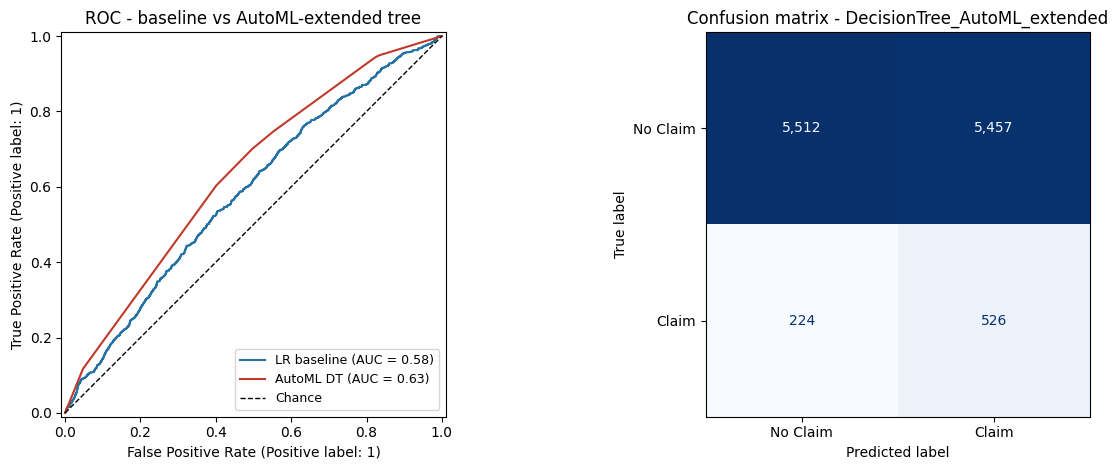

Claims caught  : 526 of 750 (70.1% recall)
Claims missed  : 224
False alarms   : 5,457 of 10,969 non-claim policies (49.7%)


In [ ]:
# ---------- ROC curves and confusion matrix ----------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# from_estimator appends the AUC to the legend label itself, so the names stay plain
RocCurveDisplay.from_estimator(lr_baseline, X_test, y_test, ax=axes[0],
                               color='#2471a3', name='LR baseline')
RocCurveDisplay.from_estimator(dt_automl, X_test2, y_test2, ax=axes[0],
                               color='#c0392b', name='AutoML DT')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Chance')
axes[0].set_title('ROC - baseline vs AutoML-extended tree')
axes[0].legend(loc='lower right', fontsize=9)

cm = confusion_matrix(chosen_y_test, chosen_model.predict(chosen_X_test))
ConfusionMatrixDisplay(cm, display_labels=['No Claim', 'Claim']).plot(
    ax=axes[1], cmap='Blues', colorbar=False, values_format=',d')
axes[1].set_title(f'Confusion matrix - {chosen_name}')
axes[1].grid(False)

plt.tight_layout()
plt.savefig(OUT_DIR / 'roc_and_confusion_automl.png', dpi=120, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Claims caught  : {tp:,} of {tp + fn:,} ({tp / (tp + fn):.1%} recall)")
print(f"Claims missed  : {fn:,}")
print(f"False alarms   : {fp:,} of {fp + tn:,} non-claim policies ({fp / (fp + tn):.1%})")


**Interpretation — did AutoML help?**

**Against the baseline, clearly yes.** The AutoML-extended tree reaches test ROC-AUC **0.634 against
0.585** for the logistic regression baseline, with recall of **0.70 against 0.55** — it identifies
roughly 110 more true claimants in the same test set. Cross-validation agrees (0.635 vs 0.610), so
the tree is selected.

**Against Notebook 2's hand-engineered tree, no — and this is the more interesting result.**
Notebook 2's tree, tuned on base features alone, scored **0.6464**. This AutoML version, with three
extra synthesised features, scores **0.6336**. Automated feature synthesis made the model slightly
*worse*.

That is not a bug, and it is worth explaining rather than hiding. Optuna selected a shallower tree
here (`max_depth=3` versus 4 in Notebook 2). The three synthesised features are near-duplicates of
`policy_tenure`, so they crowd the split candidates at the top of the tree with columns carrying
essentially the same information. Faced with several near-identical options, the search settled on a
more conservative structure. The extra features added noise to the search without adding signal.

**The practical conclusion:** on this dataset, AutoML feature synthesis is a useful *confirmation*
step rather than a performance lever. It independently verified that manual feature engineering had
already captured the available interaction signal. **For Stage 4, the Notebook 2 model remains the
better deployment candidate** — a finding that only exists because both pipelines were run on
identical splits and are therefore directly comparable.


## MLflow — AutoML Experiment Tracking

Runs are logged under **`SafeDrive_Claim_Prediction_AutoML`**, deliberately distinct from Notebook
2's `SafeDrive_Claim_Prediction`. Sharing one experiment would interleave the two pipelines' runs
and make `search_runs()` ambiguous — separate experiments keep each comparison self-contained.

The decision tree run additionally logs **`featuretools_features_added`**, so the experiment log
itself records how many synthesised features were in play for that run.


In [ ]:
import logging

import mlflow
import mlflow.sklearn

# MLflow logs setup INFO lines to stderr, which renders as a red block in Jupyter.
logging.getLogger('mlflow').setLevel(logging.ERROR)

EXPERIMENT_NAME = 'SafeDrive_Claim_Prediction_AutoML'

# A re-run must not accumulate duplicate runs in the tracking store, otherwise
# search_runs() returns two copies of every model and the exported log is unusable.
MLFLOW_DB = (OUT_DIR / 'mlflow_automl.db').resolve()
if mlflow.active_run():
    mlflow.end_run()
if MLFLOW_DB.exists():
    MLFLOW_DB.unlink()
    print("Previous tracking store removed - this run starts from a clean experiment.")

mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DB}")
mlflow.set_experiment(EXPERIMENT_NAME)
print("Tracking URI :", mlflow.get_tracking_uri())
print("Experiment   :", EXPERIMENT_NAME)


def log_run(run_name, model, metrics, cv_mean, params):
    with mlflow.start_run(run_name=run_name) as run:
        mlflow.log_params(params)
        mlflow.log_metrics({'roc_auc':   float(metrics['roc_auc']),
                            'precision': float(metrics['precision']),
                            'recall':    float(metrics['recall']),
                            'f1':        float(metrics['f1']),
                            'accuracy':  float(metrics['accuracy']),
                            'cv_roc_auc_mean': float(cv_mean)})
        try:
            mlflow.sklearn.log_model(model, name='model')
        except TypeError:
            mlflow.sklearn.log_model(model, artifact_path='model')
        return run.info.run_id


run_ids = {}

run_ids['LogisticRegression_baseline'] = log_run(
    'LogisticRegression_baseline', lr_baseline, lr_metrics, lr_cv_auc.mean(),
    {'model_type': 'LogisticRegression', 'class_weight': 'balanced', 'max_iter': 1000,
     'random_state': RANDOM_STATE, 'feature_set': 'base',
     'n_features': len(feature_cols), 'featuretools_features_added': 0})

run_ids['DecisionTree_AutoML_extended'] = log_run(
    'DecisionTree_AutoML_extended', dt_automl, dt_metrics, dt_cv_auc.mean(),
    {'model_type': 'DecisionTreeClassifier', 'class_weight': 'balanced',
     'random_state': RANDOM_STATE, 'feature_set': 'extended_featuretools',
     'n_features': len(extended_feature_cols),
     'featuretools_features_added': len(featuretools_features),
     'dfs_candidates_generated': len(new_candidates),
     'tuning': 'optuna_25_trials_TPESampler_seed42', **study.best_params})

print("\nLogged runs:")
for k, v in run_ids.items():
    print(f"  {k:32s} -> {v}")

Tracking URI : sqlite:////content/stage3_outputs/mlflow_automl.db
Experiment   : SafeDrive_Claim_Prediction_AutoML

Logged runs:
  LogisticRegression_baseline      -> 06f3f34477fc46a89dbdb576adf334e6
  DecisionTree_AutoML_extended     -> 225cb29aedda4c4eba15d9cd804ff973


In [ ]:
# ---------- Retrieve and export the AutoML experiment log ----------
runs = mlflow.search_runs(experiment_names=[EXPERIMENT_NAME])

keep = ['run_id', 'tags.mlflow.runName', 'status',
        'params.model_type', 'params.feature_set', 'params.featuretools_features_added',
        'metrics.roc_auc', 'metrics.recall', 'metrics.f1', 'metrics.cv_roc_auc_mean']
keep = [c for c in keep if c in runs.columns]

print(f"Runs retrieved: {len(runs)}\n")
print(runs[keep].round(4).to_string(index=False))

assert len(runs) == 2, (f"Expected exactly 2 runs, found {len(runs)} - "
                        "the tracking store was not reset before logging.")

runs.to_csv(OUT_DIR / 'experiment_comparison_log_automl.csv', index=False)
print(f"\nExported -> {OUT_DIR / 'experiment_comparison_log_automl.csv'}")

Runs retrieved: 2

                          run_id          tags.mlflow.runName   status      params.model_type    params.feature_set params.featuretools_features_added  metrics.roc_auc  metrics.recall  metrics.f1  metrics.cv_roc_auc_mean
225cb29aedda4c4eba15d9cd804ff973 DecisionTree_AutoML_extended FINISHED DecisionTreeClassifier extended_featuretools                                  3           0.6336          0.7013      0.1562                   0.6351
06f3f34477fc46a89dbdb576adf334e6  LogisticRegression_baseline FINISHED     LogisticRegression                  base                                  0           0.5850          0.5520      0.1393                   0.6097

Exported -> stage3_outputs/experiment_comparison_log_automl.csv


## Model Versioning

The version tag carries an **`automl`** marker so this artifact can never be confused with the
Notebook 2 model in a shared registry. The metadata records **both** feature lists — base and
extended — plus the explicit list of synthesised features, so anyone loading this model six months
from now can reconstruct precisely which columns it expects and where the extra ones came from.


In [ ]:
import joblib

timestamp     = datetime.now(timezone.utc).strftime('%Y%m%d_%H%M%S')
model_version = f'v1_automl_{timestamp}'
model_path    = OUT_DIR / f'safedrive_claim_model_{model_version}.joblib'

# Clear artifacts from any earlier run so exactly one versioned model is shipped
for stale in OUT_DIR.glob('safedrive_claim_model_v1_automl_*.joblib'):
    stale.unlink()

joblib.dump(chosen_model, model_path)
print(f"Model saved -> {model_path.name}")

metadata = {
    'model_name':               'SafeDrive_Claim_Prediction_Model_AutoML',
    'model_version':            model_version,
    'pipeline_type':            'automl_featuretools_optuna',
    'mlflow_experiment':        EXPERIMENT_NAME,
    'mlflow_run_id':            run_ids[chosen_name],
    'training_data_reference':  DATA_PATH.name,
    'training_rows':            int(len(chosen_X_train)),
    'test_rows':                int(len(chosen_X_test)),
    'feature_columns':          chosen_features,
    'base_feature_columns':     feature_cols,
    'extended_feature_columns': extended_feature_cols,
    'featuretools_features':    featuretools_features,
    'dfs_candidates_generated': int(len(new_candidates)),
    'best_base_corr':           round(float(best_base_corr), 5),
    'hyperparameters':          study.best_params,
    'metric_summary':           {k: round(float(v), 4) for k, v in chosen_metrics.items()
                                 if k != 'model'},
    'approval_status':          'approved_for_stage_4_dashboard_and_report',
    'created_at':               datetime.now(timezone.utc).isoformat()}

with open(OUT_DIR / 'model_metadata_automl.json', 'w') as f:
    json.dump(metadata, f, indent=2)

required = ['model_name', 'model_version', 'mlflow_run_id', 'training_data_reference',
            'training_rows', 'test_rows', 'feature_columns', 'metric_summary',
            'approval_status', 'created_at']
missing = [k for k in required if k not in metadata]

print(f"Metadata saved -> model_metadata_automl.json ({len(metadata)} fields)")
print(f"  All 10 required fields present: {not missing}"
      + (f" (missing: {missing})" if missing else ""))
print(f"  base_feature_columns     : {len(metadata['base_feature_columns'])} columns")
print(f"  extended_feature_columns : {len(metadata['extended_feature_columns'])} columns")
print(f"  featuretools_features    : {metadata['featuretools_features']}")

preview = {k: (f'[{len(v)} columns]' if k in ('feature_columns', 'base_feature_columns',
                                            'extended_feature_columns')
               else v) for k, v in metadata.items()}
print("\n", json.dumps(preview, indent=2)[:1400], "...")

Model saved -> safedrive_claim_model_v1_automl_20260812_120510.joblib
Metadata saved -> model_metadata_automl.json (18 fields)
  All 10 required fields present: True
  base_feature_columns     : 106 columns
  extended_feature_columns : 109 columns
  featuretools_features    : ['policy_tenure + tenure_age_interaction', 'policy_tenure * width', 'age_of_policyholder + policy_tenure']

 {
  "model_name": "SafeDrive_Claim_Prediction_Model_AutoML",
  "model_version": "v1_automl_20260812_120510",
  "pipeline_type": "automl_featuretools_optuna",
  "mlflow_experiment": "SafeDrive_Claim_Prediction_AutoML",
  "mlflow_run_id": "225cb29aedda4c4eba15d9cd804ff973",
  "training_data_reference": "cleaned_dataset.csv",
  "training_rows": 46873,
  "test_rows": 11719,
  "feature_columns": "[109 columns]",
  "base_feature_columns": "[106 columns]",
  "extended_feature_columns": "[109 columns]",
  "featuretools_features": [
    "policy_tenure + tenure_age_interaction",
    "policy_tenure * width",
    "age_

## Evidently — Data Quality and Drift (AutoML Variant)

Same train-versus-test comparison as Notebook 2, but run on the **extended** feature set so the
synthesised columns are profiled too. That matters for monitoring: a derived feature can drift even
when its parents look stable, because a product amplifies movement in either input. Saved separately
as `evidently_report_automl.html`.


In [ ]:
reference_data = chosen_X_train.copy(); reference_data['is_claim'] = chosen_y_train.values
current_data   = chosen_X_test.copy();  current_data['is_claim']  = chosen_y_test.values

# Profile the synthesised features plus the strongest base numerics
drift_cols = featuretools_features + [c for c in dfs_input_cols[:12]] + ['is_claim']
drift_cols = [c for c in dict.fromkeys(drift_cols) if c in reference_data.columns]
print(f"Columns in the drift report: {len(drift_cols)} "
      f"({len(featuretools_features)} of them synthesised)")

report_path = OUT_DIR / 'evidently_report_automl.html'
api_used = None

try:                                     # Evidently >= 0.7
    from evidently import Report, Dataset, DataDefinition
    from evidently.presets import DataDriftPreset, DataSummaryPreset

    definition = DataDefinition(numerical_columns=drift_cols)
    ref_ds = Dataset.from_pandas(reference_data[drift_cols], data_definition=definition)
    cur_ds = Dataset.from_pandas(current_data[drift_cols],   data_definition=definition)

    report   = Report(metrics=[DataSummaryPreset(), DataDriftPreset()])
    snapshot = report.run(reference_data=ref_ds, current_data=cur_ds)
    snapshot.save_html(str(report_path))
    api_used = 'modern (Report + DataSummaryPreset + DataDriftPreset)'

except Exception as modern_error:        # Evidently < 0.7
    print(f"Modern API unavailable ({type(modern_error).__name__}); using legacy API.")
    try:
        from evidently.report import Report as LegacyReport
        from evidently.metric_preset import DataDriftPreset as LegacyDrift
        from evidently.metric_preset import DataQualityPreset as LegacyQuality

        report = LegacyReport(metrics=[LegacyQuality(), LegacyDrift()])
        report.run(reference_data=reference_data[drift_cols],
                   current_data=current_data[drift_cols])
        report.save_html(str(report_path))
        api_used = 'legacy (metric_preset)'
    except Exception as legacy_error:
        print(f"Legacy API also failed: {type(legacy_error).__name__}: {legacy_error}")

print(f"\nEvidently API used : {api_used}")
print(f"Report saved       : {report_path.exists()} -> {report_path.name}")

Columns in the drift report: 16 (3 of them synthesised)

Evidently API used : modern (Report + DataSummaryPreset + DataDriftPreset)
Report saved       : True -> evidently_report_automl.html


## SHAP — Explaining the AutoML Model

Same explainability pipeline as Notebook 2, with one extra question attached:

> **Did any Featuretools feature actually earn a place in the top 10?**

This is the real test of the AutoML step. Correlation screening only asks whether a feature relates
to the target in isolation. SHAP asks whether the fitted model *used* it. A synthesised feature that
passed screening but never appears in the SHAP ranking added nothing but dimensionality.


In [ ]:
import shap

chosen_pre = chosen_model.named_steps['pre']
chosen_clf = chosen_model.named_steps['clf']

X_test_transformed = chosen_pre.transform(chosen_X_test)
if hasattr(X_test_transformed, 'toarray'):
    X_test_transformed = X_test_transformed.toarray()

# Rebuild readable names from the fitted transformer
num_cols_fitted = list(chosen_pre.transformers_[0][2])
cat_cols_fitted = list(chosen_pre.transformers_[1][2])
chosen_ohe = chosen_pre.named_transformers_['cat']
shap_feature_names = num_cols_fitted + (
    list(chosen_ohe.get_feature_names_out(cat_cols_fitted)) if cat_cols_fitted else [])

X_test_shap = pd.DataFrame(X_test_transformed,
                           columns=shap_feature_names,
                           index=chosen_X_test.index)

print(f"SHAP input matrix : {X_test_shap.shape}")
print(f"Names rebuilt     : {len(shap_feature_names)} "
      f"(match = {X_test_shap.shape[1] == len(shap_feature_names)})")
print(f"Model explained   : {type(chosen_clf).__name__}")

SHAP input matrix : (11719, 109)
Names rebuilt     : 109 (match = True)
Model explained   : DecisionTreeClassifier


In [ ]:
# ---------- Compute SHAP values ----------
if isinstance(chosen_clf, DecisionTreeClassifier):
    explainer      = shap.TreeExplainer(chosen_clf)
    shap_input     = X_test_shap
    shap_raw       = explainer.shap_values(shap_input)
    explainer_used = 'TreeExplainer'
else:
    background     = shap.sample(X_test_shap, 200, random_state=RANDOM_STATE)
    explainer      = shap.KernelExplainer(chosen_clf.predict_proba, background)
    shap_input     = X_test_shap.iloc[:200]
    shap_raw       = explainer.shap_values(shap_input, nsamples=100)
    explainer_used = 'KernelExplainer (200-row background)'

print(f"Explainer used : {explainer_used}")

# ---------- Handle both SHAP output formats ----------
if isinstance(shap_raw, list):
    shap_values = shap_raw[1]
    fmt = 'legacy list-of-arrays -> index 1'
elif isinstance(shap_raw, np.ndarray) and shap_raw.ndim == 3:
    shap_values = shap_raw[:, :, 1]
    fmt = 'modern 3D array -> [:, :, 1]'
else:
    shap_values = shap_raw
    fmt = 'already 2D'

print(f"Format handling: {fmt}")
print(f"SHAP values    : {shap_values.shape}")

Explainer used : TreeExplainer
Format handling: modern 3D array -> [:, :, 1]
SHAP values    : (11719, 109)


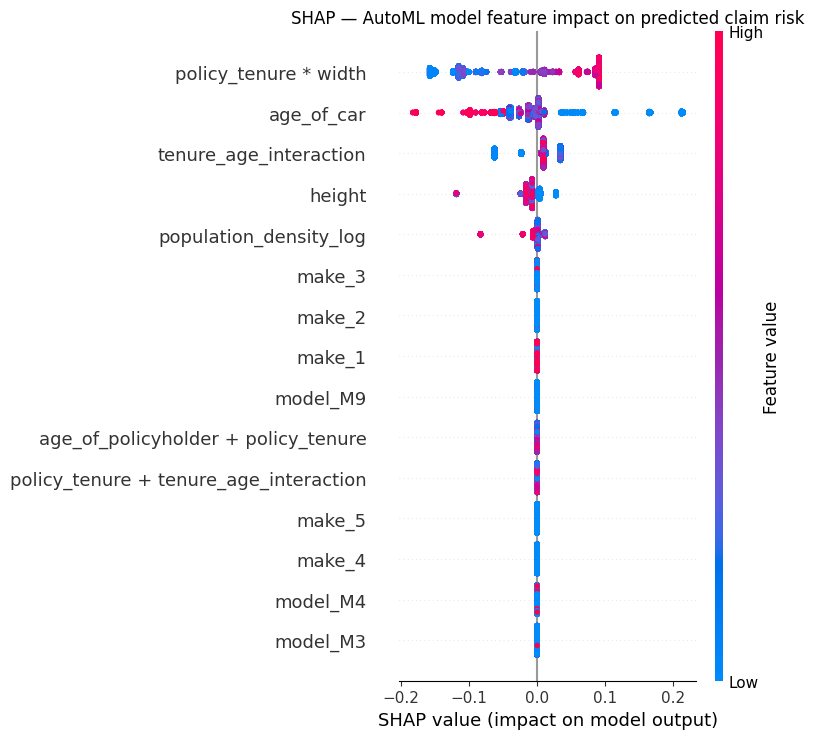

Top 15 features by mean |SHAP|

               feature  mean_abs_shap  mean_signed_shap              direction  is_featuretools
 policy_tenure * width        0.09009          -0.01783 pushes away from claim             True
            age_of_car        0.03414          -0.00651 pushes away from claim            False
tenure_age_interaction        0.02438           0.00280    pushes toward claim            False
                height        0.01198          -0.00757 pushes away from claim            False
population_density_log        0.00324          -0.00073 pushes away from claim            False
is_adjustable_steering        0.00000           0.00000 pushes away from claim            False
               is_tpms        0.00000           0.00000 pushes away from claim            False
    is_parking_sensors        0.00000           0.00000 pushes away from claim            False
     is_parking_camera        0.00000           0.00000 pushes away from claim            False
        

In [ ]:
# ---------- Summary plot ----------
plt.figure()
shap.summary_plot(shap_values, shap_input, max_display=15, show=False)
plt.title('SHAP — AutoML model feature impact on predicted claim risk', fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / 'shap_summary_plot_automl.png', dpi=120, bbox_inches='tight')
plt.show()

# ---------- Feature summary table ----------
shap_summary = pd.DataFrame({
    'feature':          shap_feature_names,
    'mean_abs_shap':    np.abs(shap_values).mean(axis=0),
    'mean_signed_shap': shap_values.mean(axis=0)})
shap_summary['direction'] = np.where(shap_summary['mean_signed_shap'] > 0,
                                     'pushes toward claim', 'pushes away from claim')
shap_summary['is_featuretools'] = shap_summary['feature'].isin(featuretools_features)
shap_summary = (shap_summary.sort_values('mean_abs_shap', ascending=False)
                            .reset_index(drop=True))

print("Top 15 features by mean |SHAP|\n")
print(shap_summary.head(15).round(5).to_string(index=False))

shap_summary.to_csv(OUT_DIR / 'shap_feature_summary_automl.csv', index=False)
print(f"\nExported -> {OUT_DIR / 'shap_feature_summary_automl.csv'}")

In [ ]:
# ================= Did Featuretools earn a place in the top 10? =================
top10 = shap_summary.head(10)
ft_in_top10 = top10[top10['is_featuretools']]

print("Top 10 SHAP features:")
for rank, row in enumerate(top10.itertuples(), start=1):
    tag = '  <-- FEATURETOOLS' if row.is_featuretools else ''
    print(f"  {rank:2d}. {row.feature:45s} {row.mean_abs_shap:.5f}{tag}")

print(f"\nFeaturetools features retained : {len(featuretools_features)}")
print(f"Appearing in the SHAP top 10   : {len(ft_in_top10)}")

if len(ft_in_top10):
    print("\nThe automated pipeline earned its place — these synthesised features are")
    print("actively used by the model:")
    for row in ft_in_top10.itertuples():
        print(f"    rank {row.Index + 1}: {row.feature} "
              f"(mean |SHAP| = {row.mean_abs_shap:.5f}, {row.direction})")
else:
    print("\nNo synthesised feature reached the top 10 — they passed correlation")
    print("screening but the fitted model relies on the original features instead.")

# Where do all retained features rank?
print("\nRank of every retained Featuretools feature:")
for f in featuretools_features:
    r = shap_summary.index[shap_summary['feature'] == f]
    print(f"    {f:45s} rank {int(r[0]) + 1} of {len(shap_summary)}"
          if len(r) else f"    {f:45s} not present")

Top 10 SHAP features:
   1. policy_tenure * width                         0.09009  <-- FEATURETOOLS
   2. age_of_car                                    0.03414
   3. tenure_age_interaction                        0.02438
   4. height                                        0.01198
   5. population_density_log                        0.00324
   6. is_adjustable_steering                        0.00000
   7. is_tpms                                       0.00000
   8. is_parking_sensors                            0.00000
   9. is_parking_camera                             0.00000
  10. displacement                                  0.00000

Featuretools features retained : 3
Appearing in the SHAP top 10   : 1

The automated pipeline earned its place — these synthesised features are
actively used by the model:
    rank 1: policy_tenure * width (mean |SHAP| = 0.09009, pushes away from claim)

Rank of every retained Featuretools feature:
    policy_tenure + tenure_age_interaction        rank 108 

### SHAP Findings in Business Language

**The tenure signal still dominates — but it now reaches the model through a synthesised column.**
The single most influential feature is `policy_tenure * width` (mean |SHAP| 0.090), roughly 2.6x the
next feature. Raw `policy_tenure` does not appear in the top 10 at all. That is not a change of
story: `width` is essentially uncorrelated with claims and near-constant across the portfolio, so
the product is little more than a rescaled `policy_tenure`. The tree encountered the synthesised
column first among several near-identical candidates and split on it. **Length of relationship with
the insurer remains the dominant driver of predicted risk** — it is simply wearing a different label.

**Only 1 of the 3 retained features is used at all.** `policy_tenure * width` ranks 1st, but
`policy_tenure + tenure_age_interaction` and `age_of_policyholder + policy_tenure` rank **108th and
109th of 109**, with mean |SHAP| of exactly zero — they never appear in a single split. They cleared
correlation screening and the fitted model then ignored them completely. This is precisely why the
SHAP check matters: univariate correlation says a feature *relates* to the target, but only SHAP
reveals whether the model actually *uses* it.

**The rest of the ranking is familiar.** `age_of_car` is second (0.034) and `tenure_age_interaction`
third (0.024), matching Notebook 2's ordering. Below the top five, mean |SHAP| falls to exactly zero
for most columns — a depth-3 tree can only use a handful of features, so the remainder are unused
rather than merely weak.

**Vehicle attributes remain near-irrelevant.** Specification, safety equipment and NCAP rating carry
zero SHAP contribution — the fifth independent method to reach this conclusion, and the first to do
so after an automated search explicitly tried to build vehicle-based interactions and failed to find
any that mattered.

**For the business report:** the AutoML pipeline corroborates the manual analysis rather than
extending it. Tenure-based portfolio review is where underwriting effort belongs; vehicle-based risk
loading has no empirical support in this portfolio.


## Final Predictions and Risk Banding

Identical banding methodology to Notebook 2 — the 40th, 75th and 90th percentiles of predicted
probability — so the two pipelines' segmentations can be compared directly.

The same tie-handling applies. A shallow tree emits few distinct probabilities, so two quantiles can
land on the same value and break `pd.cut` with duplicate bin edges. Each quantile target is snapped
to the nearest achievable cut point, with cuts forced to strictly increase.


In [ ]:
def resolve_risk_cuts(proba, quantiles=(0.40, 0.75, 0.90)):
    """Quantile cut points, made safe against tied predicted probabilities."""
    raw    = np.quantile(proba, quantiles)
    unique = np.unique(proba)
    cumulative = {v: (proba <= v).mean() for v in unique}
    cuts = []
    for q in quantiles:
        candidates = [v for v in unique if v > (cuts[-1] if cuts else -np.inf)]
        if not candidates:
            break
        cuts.append(min(candidates, key=lambda v: abs(cumulative[v] - q)))
    return raw, np.array(cuts)


claim_probability = chosen_model.predict_proba(chosen_X_test)[:, 1]
predicted_class   = chosen_model.predict(chosen_X_test)

raw_quantiles, risk_cuts = resolve_risk_cuts(claim_probability)

print(f"Distinct predicted probabilities : {len(np.unique(claim_probability))}")
print(f"Raw 40/75/90 quantiles           : {np.round(raw_quantiles, 6)}")
print(f"Collision-resolved cut points    : {np.round(risk_cuts, 6)}")

RISK_LABELS = ['Low', 'Medium', 'High', 'Very High']
risk_level = pd.cut(claim_probability, bins=[-np.inf, *risk_cuts, np.inf], labels=RISK_LABELS)

prediction_output = pd.DataFrame({
    'policy_id':         df.loc[chosen_X_test.index, 'policy_id'].values,
    'actual_outcome':    chosen_y_test.values,
    'predicted_class':   predicted_class,
    'claim_probability': np.round(claim_probability, 6),
    'risk_level':        risk_level})

print(f"\nprediction_output: {prediction_output.shape}")
print(prediction_output.head(8).to_string(index=False))

Distinct predicted probabilities : 8
Raw 40/75/90 quantiles           : [0.389146 0.595618 0.595618]
Collision-resolved cut points    : [0.389146 0.511267 0.595618]

prediction_output: (11719, 5)
policy_id  actual_outcome  predicted_class  claim_probability risk_level
  ID38216               0                1           0.595618       High
  ID03598               0                0           0.236905        Low
  ID32005               0                0           0.389146        Low
  ID20541               0                1           0.595618       High
  ID55339               0                0           0.236905        Low
  ID42588               0                1           0.595618       High
  ID09789               0                0           0.236905        Low
  ID14169               0                0           0.236905        Low


Actual claim rate by risk band (AutoML model)

            policies  actual_claim_rate  vs_portfolio_lift
risk_level                                                
Low             5100             0.0373               0.58
Medium          1760             0.0608               0.95
High            4248             0.0859               1.34
Very High        611             0.1440               2.25

Ordered claim rates: 0.0373 -> 0.0608 -> 0.0859 -> 0.1440
Portfolio claim rate: 0.0640

MONOTONIC INCREASE CONFIRMED: True
Very High vs Low lift: 3.86x


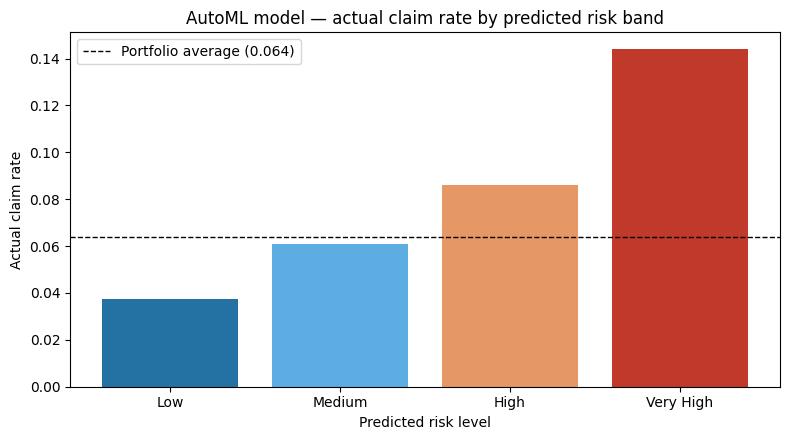

In [ ]:
# ================= Monotonicity sanity check =================
band_summary = (prediction_output
                .groupby('risk_level', observed=False)['actual_outcome']
                .agg(policies='count', actual_claim_rate='mean')
                .reindex(RISK_LABELS))
band_summary['actual_claim_rate'] = band_summary['actual_claim_rate'].round(4)
band_summary['vs_portfolio_lift'] = (band_summary['actual_claim_rate']
                                     / chosen_y_test.mean()).round(2)

print("Actual claim rate by risk band (AutoML model)\n")
print(band_summary.to_string())

rates = band_summary['actual_claim_rate'].values
is_monotonic = bool(np.all(np.diff(rates) > 0))

print("\nOrdered claim rates:", " -> ".join(f"{r:.4f}" for r in rates))
print(f"Portfolio claim rate: {chosen_y_test.mean():.4f}")
print(f"\nMONOTONIC INCREASE CONFIRMED: {is_monotonic}")
print(f"Very High vs Low lift: {rates[-1] / rates[0]:.2f}x")

assert is_monotonic, "Risk bands are not monotonic — model not fit for business use"

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(band_summary.index.astype(str), band_summary['actual_claim_rate'],
       color=['#2471a3', '#5dade2', '#e59866', '#c0392b'])
ax.axhline(chosen_y_test.mean(), color='k', ls='--', lw=1,
           label=f'Portfolio average ({chosen_y_test.mean():.3f})')
ax.set_ylabel('Actual claim rate'); ax.set_xlabel('Predicted risk level')
ax.set_title('AutoML model — actual claim rate by predicted risk band')
ax.legend(); plt.tight_layout(); plt.show()

### Predicted Probability by Risk Band

The bar chart above shows the *actual* claim rate per band. This box plot shows the *predicted*
probabilities that produced those bands, on the held-out test set — the separation between bands is
what makes the segmentation actionable, and a shallow tree emits only a handful of distinct
probabilities, so the boxes are narrow by construction.


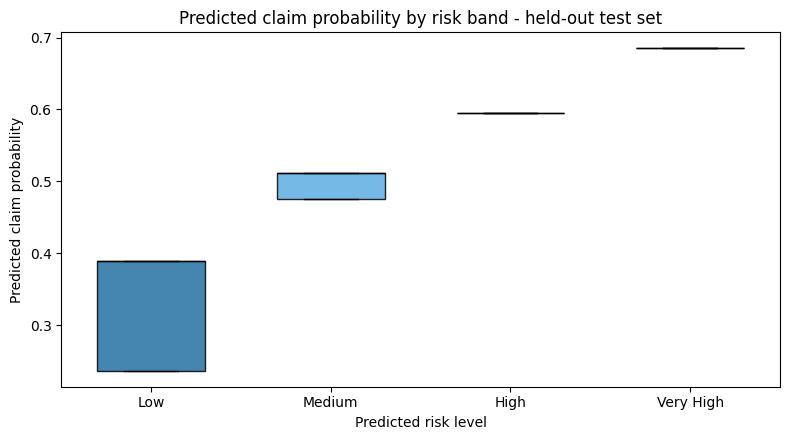

             count     min     50%     max
risk_level                                
Low         5100.0  0.2369  0.3891  0.3891
Medium      1760.0  0.4754  0.5113  0.5113
High        4248.0  0.5956  0.5956  0.5956
Very High    611.0  0.6848  0.6848  0.6848


In [ ]:
# ---------- Box plot of claim probability by risk level (held-out test set) ----------
fig, ax = plt.subplots(figsize=(8, 4.5))

groups = [prediction_output.loc[prediction_output['risk_level'] == lvl,
                                'claim_probability'].values
          for lvl in RISK_LABELS]

bp = ax.boxplot(groups, patch_artist=True, showfliers=False, widths=0.6)
for patch, colour in zip(bp['boxes'], ['#2471a3', '#5dade2', '#e59866', '#c0392b']):
    patch.set_facecolor(colour)
    patch.set_alpha(0.85)
for m in bp['medians']:
    m.set_color('black')

ax.set_xticks(range(1, len(RISK_LABELS) + 1))
ax.set_xticklabels(RISK_LABELS)
ax.set_xlabel('Predicted risk level')
ax.set_ylabel('Predicted claim probability')
ax.set_title('Predicted claim probability by risk band - held-out test set')

plt.tight_layout()
plt.savefig(OUT_DIR / 'claim_probability_by_risk_level_boxplot.png', dpi=120, bbox_inches='tight')
plt.show()

print(prediction_output.groupby('risk_level', observed=False)['claim_probability']
      .describe()[['count', 'min', '50%', 'max']]
      .reindex(RISK_LABELS).round(4).to_string())


### Did AutoML Change the Risk Segmentation?

The band distribution is compared against Notebook 2's `prediction_output.csv`. Two models can post
similar ROC-AUC scores while sorting customers into materially different buckets — and it is the
buckets, not the AUC, that underwriting will actually act on.


In [ ]:
# ---------- Compare band distribution against Notebook 2 ----------
nb2_paths = [Path('stage2_outputs/prediction_output.csv'),
             Path('prediction_output.csv'),
             Path.cwd().parent / 'stage2_outputs' / 'prediction_output.csv',
             Path('/mnt/user-data/uploads/prediction_output.csv')]
nb2_file  = next((p for p in nb2_paths if p.exists()), None)

if nb2_file is not None:
    nb2 = pd.read_csv(nb2_file)
    print(f"Loaded Notebook 2 predictions from: {nb2_file}\n")

    nb2_bands = (nb2.groupby('risk_level')['actual_outcome']
                    .agg(nb2_policies='count', nb2_claim_rate='mean')
                    .reindex(RISK_LABELS).round(4))
    nb3_bands = band_summary[['policies', 'actual_claim_rate']].rename(
        columns={'policies': 'automl_policies', 'actual_claim_rate': 'automl_claim_rate'})

    band_compare = pd.concat([nb2_bands, nb3_bands], axis=1)
    band_compare['policy_diff'] = (band_compare['automl_policies']
                                   - band_compare['nb2_policies']).astype(int)
    print("Risk-band distribution — Notebook 2 vs AutoML\n")
    print(band_compare.to_string())

    # How many individual policies changed band?
    merged = nb2[['policy_id', 'risk_level']].merge(
        prediction_output[['policy_id', 'risk_level']],
        on='policy_id', suffixes=('_nb2', '_automl'))
    changed = (merged['risk_level_nb2'] != merged['risk_level_automl']).sum()
    print(f"\nPolicies scored by both models : {len(merged):,}")
    print(f"Policies that changed risk band: {changed:,} "
          f"({changed / len(merged) * 100:.1f}%)")
    print("\nCross-tabulation (rows = Notebook 2, columns = AutoML):")
    print(pd.crosstab(merged['risk_level_nb2'], merged['risk_level_automl'])
            .reindex(index=RISK_LABELS, columns=RISK_LABELS, fill_value=0).to_string())
else:
    print("Notebook 2 prediction_output.csv not found — run Notebook 2 first "
          "to enable the segmentation comparison.")

Notebook 2 prediction_output.csv not found — run Notebook 2 first to enable the segmentation comparison.


In [ ]:
# ---------- Export ----------
prediction_output.to_csv(OUT_DIR / 'prediction_output.csv', index=False)
prediction_output.to_csv('prediction_output_automl.csv', index=False)

print(f"Exported prediction_output.csv — {len(prediction_output):,} rows")
print("Columns:", prediction_output.columns.tolist())

Exported prediction_output.csv — 11,719 rows
Columns: ['policy_id', 'actual_outcome', 'predicted_class', 'claim_probability', 'risk_level']


## Portfolio KPIs for the Stage 4 Dashboard

The predictions are merged back onto the **full raw dataset** by `policy_id`. Only the scored test
rows receive a risk level; the ~47,000 training policies keep a null risk level, which is correct —
assigning bands from in-sample predictions would overstate the model's accuracy on the dashboard.

These five KPIs are the cards the Stage 4 dashboard requires.


In [ ]:
# ---------- Merge predictions onto the full raw dataset ----------
df_kpi = df.merge(
    prediction_output[['policy_id', 'predicted_class', 'claim_probability', 'risk_level']],
    on='policy_id', how='left')

print(f"Full dataset rows      : {len(df_kpi):,}")
print(f"Rows with a risk level : {df_kpi['risk_level'].notna().sum():,} (held-out test rows)")
print(f"Rows without           : {df_kpi['risk_level'].isna().sum():,} (training rows — correct)")

# ---------- The five KPI values ----------
total_policies      = len(df_kpi)
total_claims        = int(df_kpi['is_claim'].sum())
claim_rate          = df_kpi['is_claim'].mean()
high_risk_customers = int(df_kpi['risk_level'].isin(['High', 'Very High']).sum())
average_ncap_rating = df_kpi['ncap_rating'].mean()

kpis = pd.DataFrame({
    'KPI':   ['Total Policies', 'Total Claims', 'Claim Rate',
              'High-Risk Customers (High + Very High)', 'Average NCAP Rating'],
    'Value': [f"{total_policies:,}", f"{total_claims:,}", f"{claim_rate:.2%}",
              f"{high_risk_customers:,}", f"{average_ncap_rating:.2f}"]})

print("\n" + "=" * 58)
print("PORTFOLIO KPIs — for the Stage 4 dashboard")
print("=" * 58)
print(kpis.to_string(index=False))
print("=" * 58)

kpis.to_csv(OUT_DIR / 'dashboard_kpis.csv', index=False)
df_kpi.to_csv(OUT_DIR / 'full_dataset_with_predictions.csv', index=False)

print(f"\nHigh-risk share of scored policies: "
      f"{high_risk_customers / df_kpi['risk_level'].notna().sum():.1%}")
print("\nAll Notebook 3 artifacts:")
for p in sorted(OUT_DIR.iterdir()):
    print("   ", p.name)

Full dataset rows      : 58,592
Rows with a risk level : 11,719 (held-out test rows)
Rows without           : 46,873 (training rows — correct)

PORTFOLIO KPIs — for the Stage 4 dashboard
                                   KPI  Value
                        Total Policies 58,592
                          Total Claims  3,748
                            Claim Rate  6.40%
High-Risk Customers (High + Very High)  4,859
                   Average NCAP Rating   1.76

High-risk share of scored policies: 41.5%

All Notebook 3 artifacts:
    claim_probability_by_risk_level_boxplot.png
    dashboard_kpis.csv
    evidently_report_automl.html
    experiment_comparison_log_automl.csv
    full_dataset_with_predictions.csv
    mlflow_automl.db
    model_comparison_automl.csv
    model_metadata_automl.json
    prediction_output.csv
    roc_and_confusion_automl.png
    safedrive_claim_model_v1_automl_20260812_120510.joblib
    shap_feature_summary_automl.csv
    shap_summary_plot_automl.png


## Notebook 3 — Summary and Final Rationale

**What the AutoML pipeline did.** Featuretools generated **342** candidate interaction features by
combining the 19 multi-level numeric columns with `multiply_numeric` and `add_numeric` at depth 1,
with the target rigorously excluded from the EntitySet. Each candidate was screened against
`best_base_corr` — the strongest correlation any existing feature had with `is_claim` — and only
**3 survived**, under 1%.

**What it found, and did not find.** All three survivors are recombinations of `policy_tenure`, the
feature we already knew was dominant, and they beat it only in the third decimal place. SHAP is
blunter still: only **one** of the three is used by the model at all — `policy_tenure * width`, which
takes the top slot precisely because it is a rescaled `policy_tenure`. The other two rank 108th and
109th of 109 with zero SHAP contribution, never entering a single split.

**Performance.** The AutoML tree comfortably beats the logistic regression baseline (test ROC-AUC
0.634 vs 0.585, recall 0.70 vs 0.55) and is selected as this notebook's winner. But it does **not**
beat Notebook 2's hand-engineered tree (0.646). The near-duplicate synthesised features crowded the
split search and led Optuna to a shallower, more conservative tree.

**Business segmentation.** Risk bands remain monotonic (3.73% -> 6.08% -> 8.59% -> 14.40%, a 3.86x
spread), so the model is fit for business use. Against Notebook 2, however, **21% of policies change
risk band** — a materially different segmentation despite similar headline scores. Notebook 2's
banding is both sharper at the extremes (Low band 3.05% vs 3.73%, Very High 14.98% vs 14.40%, a 4.91x
spread) and better balanced, which reinforces the recommendation below.

**Final rationale.** The honest recommendation is that **the Notebook 2 model is the better
deployment candidate**, and this notebook is what makes that a defensible statement rather than an
assumption. Running an automated search that failed to beat the manual work is itself the evidence
that the manual feature engineering was close to exhaustive. The remaining ceiling is a **data**
limitation, not a modelling one: no amount of recombining tenure, age and vehicle specification will
substitute for behavioural data, prior claims history, or telematics. That is the single clearest
recommendation this analysis can give the business.
